# Tracking the hedge ratio with the Kalman filter

```{admonition} Topics
:class: seealso

Kalman filter · state-space model · dynamic hedge ratio · pairs trading · OLS bootstrap · lookahead bias
```

In pairs trading, the spread between two assets is only stationary if we subtract the right
proportion of one asset from the other. That proportion — the **hedge ratio** $\beta_t$ — is
rarely constant in practice. Structural shifts in business models, changing correlations, or
regime transitions all cause the relationship to drift over time.

A constant OLS hedge ratio, estimated once on the training window, cannot adapt to these drifts.
This note derives the Kalman filter state-space model used by `spreadpy` for dynamic hedge ratio
estimation, following Palomar (2024), §15.6.3. Two variants are covered:

- the **2-state model** `KalmanFilter` — tracks the intercept $\mu_t$ and the slope $\gamma_t$
- the **3-state model** `KalmanFilterWithVelocity` — adds a velocity $\dot{\gamma}_t$ to follow
  locally linear trends

---

## Why not OLS?

Given price series $(y_t, x_t)$, the simplest hedge ratio is the full-sample OLS slope:

$$
\hat{\gamma} = \frac{\sum_t (x_t - \bar{x})(y_t - \bar{y})}{\sum_t (x_t - \bar{x})^2}.
$$

This is optimal under stationarity. But it has two critical limitations:

1. **Static** — it cannot react to regime changes occurring after the training window.
2. **Biased at boundaries** — even rolling OLS uses a fixed window of the past and discards all
   older information abruptly.

Rolling OLS with window $w$ is a middle ground:

$$
\hat{\gamma}_t = \operatorname{argmin}_{\gamma,\mu}
\sum_{s=t-w+1}^{t} (y_s - \mu - \gamma\, x_s)^2.
$$

It adapts but introduces a tuning parameter $w$ and uses observations with equal weights,
while the Kalman filter **weights all observations optimally** and updates the estimate
one observation at a time.

---

## The state-space model

### Observation and transition equations

We model the joint dynamics of $(y_t, x_t)$ as a **linear Gaussian state-space model**.
The two hidden states are the intercept $\mu_t$ and the hedge ratio $\gamma_t$.

**Observation equation** — $y_t$ is explained by $x_t$ through the current state:

$$
y_t = \mu_t + \gamma_t\, x_t + \varepsilon_t,
\qquad \varepsilon_t \sim \mathcal{N}(0, \sigma^2_\varepsilon).
$$

**Transition equations** — the states evolve as independent random walks:

$$
\mu_{t+1} = \mu_t + \eta_{\mu,t}, \qquad \eta_{\mu,t} \sim \mathcal{N}(0, \sigma^2_\mu),
$$
$$
\gamma_{t+1} = \gamma_t + \eta_{\gamma,t}, \qquad \eta_{\gamma,t} \sim \mathcal{N}(0, \sigma^2_\gamma).
$$

In matrix form, with state vector $\alpha_t = [\mu_t, \gamma_t]^\top$:

$$
\alpha_{t+1} = F\, \alpha_t + \eta_t, \quad F = I_2, \quad \eta_t \sim \mathcal{N}(0, Q),
\quad Q = \begin{pmatrix} \sigma^2_\mu & 0 \\ 0 & \sigma^2_\gamma \end{pmatrix}.
$$

At each bar $t$ the observation matrix is $H_t = [1,\, x_t]$, so the observation equation
rewrites compactly as:

$$
y_t = H_t\, \alpha_t + \varepsilon_t.
$$

### Hyperparameter initialisation (OLS bootstrap)

The three noise variances $(\sigma^2_\varepsilon, \sigma^2_\mu, \sigma^2_\gamma)$ are not
observed and must be fixed before running the filter. Following Palomar (2024), §15.6.3,
we bootstrap them from an OLS fit on the first $T_{\mathrm{ls}}$ bars:

$$
\sigma^2_\varepsilon = \mathrm{Var}[\varepsilon^{\mathrm{OLS}}],
\qquad
\sigma^2_\mu = \alpha\, \sigma^2_\varepsilon,
\qquad
\sigma^2_\gamma = \frac{\alpha\, \sigma^2_\varepsilon}{\mathrm{Var}[x]}.
$$

The scalar $\alpha \in (10^{-6}, 10^{-4})$ is the single tuning parameter: smaller values
make the states **adapt more slowly**, larger values track changes faster but add noise.

The initial state covariance is also derived from OLS precision:

$$
P_0 = \mathrm{diag}\!\left(
    \frac{\sigma^2_\varepsilon}{T_{\mathrm{ls}}},\;
    \frac{\sigma^2_\varepsilon}{T_{\mathrm{ls}}\cdot\mathrm{Var}[x]}
\right).
$$

---

## The Kalman recursion

At each bar $t = 1, \ldots, T$, the filter alternates between a **predict** step (prior
before seeing $y_t$) and an **update** step (posterior after seeing $y_t$).

**Predict:**

$$
\alpha_{t|t-1} = F\, \alpha_{t-1|t-1}, \qquad P_{t|t-1} = F\, P_{t-1|t-1}\, F^\top + Q.
$$

Since $F = I_2$, the predicted state is simply the previous filtered state —
the hedge ratio is not expected to drift between bars.

**Update** — incorporate the new observation $y_t$:

$$
\nu_t = y_t - H_t\, \alpha_{t|t-1} \qquad (\text{innovation})
$$
$$
S_t = H_t\, P_{t|t-1}\, H_t^\top + \sigma^2_\varepsilon \qquad (\text{innovation variance})
$$
$$
K_t = P_{t|t-1}\, H_t^\top / S_t \qquad (\text{Kalman gain})
$$
$$
\alpha_{t|t} = \alpha_{t|t-1} + K_t\, \nu_t, \qquad P_{t|t} = (I - K_t H_t^\top)\, P_{t|t-1}.
$$

The Kalman gain $K_t \in \mathbb{R}^2$ determines how much the new observation moves the
state estimate. When $\sigma^2_\varepsilon$ is large (noisy observations), $K_t$ is small
and the filter trusts the prior more. When $\sigma^2_\gamma$ is large (fast-moving state),
$K_t$ is large and new data dominates.

### Avoiding lookahead bias

```{admonition} Critical point
:class: warning

For trading, we must use the **predictive** state $\gamma_{t|t-1}$, not the **filtered**
state $\gamma_{t|t}$.

The filtered state $\gamma_{t|t}$ incorporates $y_t$ itself — if we used it to construct
the spread $s_t = y_t - \gamma_{t|t}\, x_t$, we would be using the future to explain
the present.

`spreadpy` always returns and uses $\gamma_{t|t-1}$.
```

The lookahead-free normalised spread is therefore:

$$
z_t = \frac{y_t - \gamma_{t|t-1}\, x_t - \mu_{t|t-1}}{1 + \gamma_{t|t-1}}.
$$

---

## The velocity extension

### Motivation

The 2-state random-walk model assumes the hedge ratio has no directional trend —
changes in $\gamma_t$ are pure noise. When the cointegration relationship drifts
persistently in one direction (e.g. a slow structural shift in business mix), the
2-state model lags behind because it cannot anticipate the direction.

The **3-state model** adds a velocity $\dot{\gamma}_t$ that lets the filter
extrapolate the current trend:

$$
\gamma_{t+1} = \gamma_t + \dot{\gamma}_t + \eta_{\gamma,t},
\qquad
\dot{\gamma}_{t+1} = \dot{\gamma}_t + \eta_{\dot{\gamma},t}.
$$

This is the **locally linear trend** (LLT) model applied to the hedge ratio.

### State equations

The augmented state vector is $\alpha_t = [\mu_t, \gamma_t, \dot{\gamma}_t]^\top$ and the
transition matrix becomes:

$$
F = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 1 & 1 \\ 0 & 0 & 1 \end{pmatrix},
\qquad
Q = \begin{pmatrix} \sigma^2_\mu & 0 & 0 \\ 0 & \sigma^2_\gamma & 0 \\ 0 & 0 & \sigma^2_{\dot{\gamma}} \end{pmatrix}.
$$

The observation matrix is $H_t = [1, x_t, 0]$, so the velocity is a **latent** variable
that only influences $y_t$ indirectly through $\gamma_t$.

The predicted hedge ratio is now:

$$
\gamma_{t|t-1} = \gamma_{t-1|t-1} + \dot{\gamma}_{t-1|t-1},
$$

which extrapolates the last estimated trend — the filter "looks ahead" in the direction
of the current drift.

### Additional hyperparameter

The velocity noise variance uses a second scale $\alpha_{\dot{\gamma}} < \alpha$:

$$
\sigma^2_{\dot{\gamma}} = \frac{\alpha_{\dot{\gamma}} \cdot \sigma^2_\varepsilon}{\mathrm{Var}[x]}.
$$

The inequality $\alpha_{\dot{\gamma}} < \alpha$ ensures the velocity is **slower-moving**
than the hedge ratio itself: the trend is persistent but not erratic. The default in
`spreadpy` is $\alpha_{\dot{\gamma}} = \alpha / 10$.

---

## Application with `spreadpy`

We illustrate the three estimators on a classic soft-commodities pair: **CC=F** (Cocoa futures)
and **KC=F** (Coffee futures). Both are agricultural commodities sensitive to weather and
supply-chain shocks, but their demand drivers differ enough that the relationship drifts over time.

### Loading data

In [1]:
import numpy as np
import yfinance as yf
from spreadpy.data import PriceTimeSeries

raw = yf.download(["CC=F", "KC=F"], start="2018-01-01", end="2024-01-01",
                  auto_adjust=True)["Close"].dropna()

y = PriceTimeSeries(raw["CC=F"], name="Cacoa")
x = PriceTimeSeries(raw["KC=F"], name="Coffee")

[                       0%                       ]

[*********************100%***********************]  2 of 2 completed

### Fitting the three estimators

In [2]:
from spreadpy.spread.hedgeRatio.constantOLS import ConstantOLS
from spreadpy.spread.hedgeRatio.rollingOLS import RollingOLS
from spreadpy.spread.hedgeRatio.kalmanFilter import KalmanFilter
from spreadpy.spread.hedgeRatio.kalmanFilterWithVelocity import KalmanFilterWithVelocity

ols     = ConstantOLS(add_intercept=False)
rolling = RollingOLS(window=120, add_intercept=False)
kf      = KalmanFilter(alpha=1e-4, add_intercept=False)
kfv     = KalmanFilterWithVelocity(alpha=1e-4, alpha_dgam=1e-6, add_intercept=False)

# All estimators work on log-prices for homoscedastic residuals
y_log = PriceTimeSeries(np.log(y.series), name="log CC=F")
x_log = PriceTimeSeries(np.log(x.series), name="log KC=F")

beta_ols     = ols.fit(y_log, x_log)
beta_rolling = rolling.fit(y_log, x_log)
beta_kf      = kf.fit(y_log, x_log)
beta_kfv     = kfv.fit(y_log, x_log)

### Comparing the hedge ratios

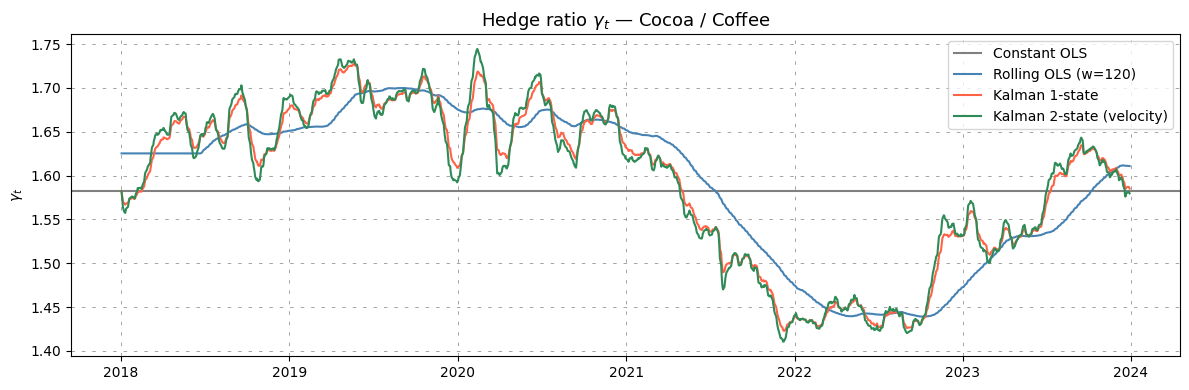

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.axhline(beta_ols.iloc[0], color="gray", lw=1.5, label="Constant OLS")
ax.plot(beta_rolling, color="steelblue", lw=1.5, label="Rolling OLS (w=120)")
ax.plot(beta_kf,      color="tomato",    lw=1.5,   label="Kalman 1-state")
ax.plot(beta_kfv,     color="seagreen",  lw=1.5,   label="Kalman 2-state (velocity)")
ax.set_title("Hedge ratio $\\gamma_t$ — Cocoa / Coffee", fontsize=13)
ax.set_ylabel("$\\gamma_t$")
ax.legend()
plt.grid(linestyle="--", dashes=(5, 10), color="gray", linewidth=0.5)
plt.tight_layout()
plt.show()

The Kalman curves adapt smoothly to structural breaks while Rolling OLS
produces step-like jumps and lags by half a window.

### Inspecting the normalised spread

Both Kalman estimators expose the normalised spread $z_t$ directly as an attribute
after `fit()`:

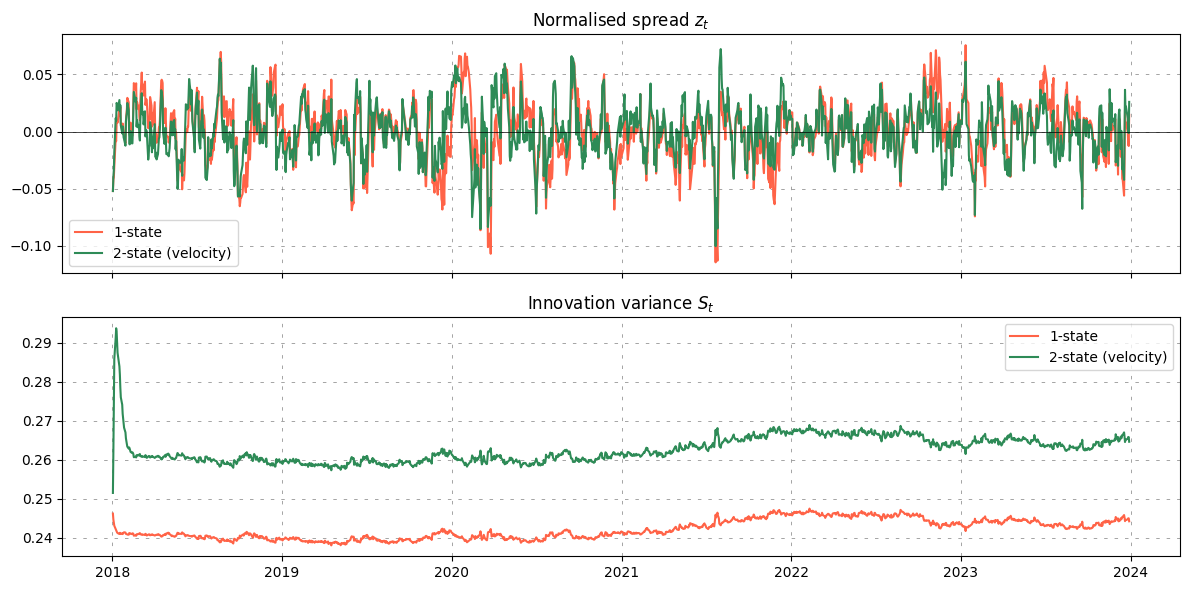

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(kf.normalized_spread_,  color="tomato",   label="1-state")
axes[0].plot(kfv.normalized_spread_, color="seagreen",  label="2-state (velocity)")
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set_title("Normalised spread $z_t$")
axes[0].legend()
axes[0].grid(linestyle="--", dashes=(5, 10), color="gray", linewidth=0.5)

axes[1].plot(kf.innovation_var_ts_,  color="tomato",   label="1-state")
axes[1].plot(kfv.innovation_var_ts_, color="seagreen",  label="2-state (velocity)")
axes[1].set_title("Innovation variance $S_t$")
axes[1].legend()
axes[1].grid(linestyle="--", dashes=(5, 10), color="gray", linewidth=0.5)

plt.tight_layout()
plt.show()

A widening $S_t$ signals that the filter is uncertain — the model and the data
are temporarily inconsistent. This often coincides with news events or regime changes.

### Stationarity diagnostics

In [5]:
from spreadpy.spread import SpreadSeries

# Build the spread series (in log-price space) with the KF hedge ratio
spread_kf = SpreadSeries(y_log, x_log, beta_kf, estimator_name="KalmanFilter")
spread_kfv = SpreadSeries(y_log, x_log, beta_kfv, estimator_name="KalmanFilterVelocity")

hl   = spread_kf.half_life()
stat, pval = spread_kf.adf_statistic()

print("For Kalman filter:")
print(f"Half-life : {hl:.1f} bars")
print(f"ADF stat  : {stat:.3f}  (p = {pval:.4f})")

hlv   = spread_kfv.half_life()
statv, pvalv = spread_kfv.adf_statistic()

print("\nFor Kalman filter with velocity:")
print(f"Half-life : {hlv:.1f} bars")
print(f"ADF stat  : {statv:.3f}  (p = {pvalv:.4f})")

For Kalman filter:
Half-life : 4.3 bars
ADF stat  : -11.511  (p = 0.0000)

For Kalman filter with velocity:
Half-life : 3.1 bars
ADF stat  : -9.586  (p = 0.0000)


A short half-life (say, 20–60 bars for daily data) and a p-value below 0.05 suggest that
the Kalman-filtered spread is mean-reverting and suitable for z-score signal generation.

The full-sample statistics give a single answer, but the spread around early 2020 shows
a clear structural break. It is more informative to track stationarity **continuously**
with a rolling ADF test.

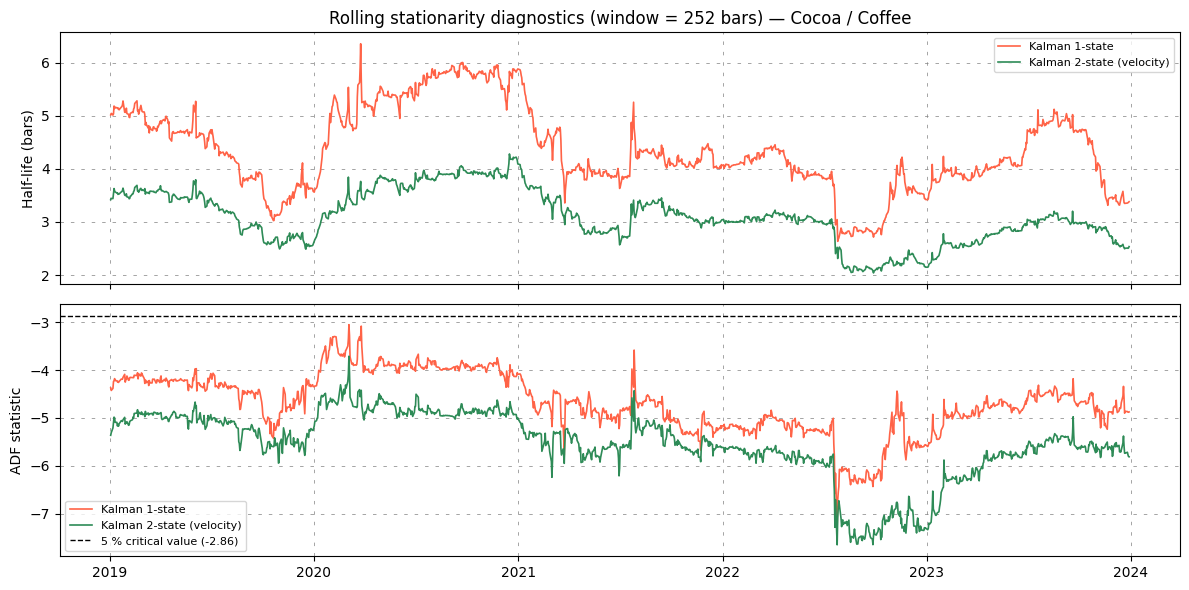

In [6]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

ROLL = 252

def rolling_diagnostics(spread, roll):
    residuals = spread.residuals.dropna()
    delta  = residuals.diff().dropna()
    lagged = residuals.shift(1).dropna()
    stats, half_lives, idx = [], [], []
    for i in range(roll, len(residuals)):
        res   = adfuller(residuals.iloc[i - roll : i], maxlag=1, autolag=None)
        s_lag = lagged.iloc[i - roll : i].values
        ds    = delta.iloc[i - roll : i].values
        b     = np.dot(s_lag, ds) / np.dot(s_lag, s_lag)
        stats.append(res[0])
        half_lives.append(-np.log(2) / b if b < 0 else np.nan)
        idx.append(residuals.index[i])
    return pd.Series(stats, index=idx), pd.Series(half_lives, index=idx)

roll_stat,   roll_hl   = rolling_diagnostics(spread_kf,  ROLL)
roll_stat_v, roll_hl_v = rolling_diagnostics(spread_kfv, ROLL)

cv_5pct = -2.86

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Panel 1 — rolling half-life
axes[0].plot(roll_hl,   color="tomato",   lw=1.2, label="Kalman 1-state")
axes[0].plot(roll_hl_v, color="seagreen", lw=1.2, label="Kalman 2-state (velocity)")
axes[0].set_ylabel("Half-life (bars)")
axes[0].legend(fontsize=8)
axes[0].set_title(f"Rolling stationarity diagnostics (window = {ROLL} bars) — Cocoa / Coffee")
axes[0].grid(linestyle="--", dashes=(5, 10), color="gray", linewidth=0.5)

# Panel 2 — rolling ADF statistic
axes[1].plot(roll_stat,   color="tomato",   lw=1.2, label="Kalman 1-state")
axes[1].plot(roll_stat_v, color="seagreen", lw=1.2, label="Kalman 2-state (velocity)")
axes[1].axhline(cv_5pct, color="black", lw=1.0, linestyle="--",
                label=f"5 % critical value ({cv_5pct})")
axes[1].fill_between(roll_stat.index, roll_stat, cv_5pct,
                     where=(roll_stat > cv_5pct), alpha=0.12, color="tomato")
axes[1].fill_between(roll_stat_v.index, roll_stat_v, cv_5pct,
                     where=(roll_stat_v > cv_5pct), alpha=0.12, color="seagreen")
axes[1].set_ylabel("ADF statistic")
axes[1].legend(fontsize=8)
axes[1].grid(linestyle="--", dashes=(5, 10), color="gray", linewidth=0.5)

plt.tight_layout()
plt.show()

The red zones in the ADF panel highlight periods where the spread temporarily loses its
mean-reverting property. A rising half-life confirms the same story from a different angle:
the spread reverts more slowly when the relationship is under stress.
Any structural break visible in the plots reflects supply or demand shocks specific to
cocoa or coffee markets — droughts, disease, or geopolitical disruptions — pushing the
relationship out of its historical range for extended periods.
This kind of diagnostic is useful for **gating the signal**: one can suspend trading
whenever the ADF statistic rises above its critical value.

---

## Choosing between the two models

| | **2-state** `KalmanFilter` | **3-state** `KalmanFilterWithVelocity` |
|---|---|---|
| Transition | Random walk on $\gamma_t$ | Locally linear trend |
| Best for | Stationary relationship with occasional jumps | Slow, persistent drifts |
| Risk of | Under-reacting to trends | Over-fitting to transient moves |
| Key param | $\alpha \in [10^{-6}, 10^{-4}]$ | $\alpha$, $\alpha_{\dot\gamma} = \alpha/10$ |
| Palomar recommendation | $\alpha = 10^{-5}$ | $\alpha = 10^{-6}$ |

```{admonition} Practical advice
:class: tip

Use the **2-state model** as the default. Switch to the **3-state model** only if
inspection of $\gamma_t$ shows a persistent directional drift that the 2-state model
cannot track without raising $\alpha$ to a level that makes the spread too noisy.

In both cases, **always use log-prices** — the constant-noise assumption
$\sigma^2_\varepsilon = \mathrm{const}$ breaks down on raw prices where
$\sigma^2_\varepsilon \propto \text{price}^2$.
```

---

## References

- Palomar, D. P. (2024). *Portfolio Optimization: Theory and Application.*
  Cambridge University Press. §15.6 — Kalman filter for pairs trading.
  [Online version](https://portfoliooptimizationbook.com/book/15.6-kalman-pairs-trading.html)
- Kalman, R. E. (1960). *A new approach to linear filtering and prediction problems.*
  Journal of Basic Engineering, 82(1), 35–45.
- Pole, A. (2007). *Statistical Arbitrage: Algorithmic Trading Insights and Techniques.*
  Wiley Finance.